## Minion Notebook

In [110]:
# (requires) setup.py, run to show version of qickdawg installed
!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [111]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from copy import copy
import qickdawg as qd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from importlib.metadata import version
version('numpy')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'2.3.3'

In [112]:
qd.start_client('192.168.3.1')

### General Config

In [113]:
default_config = qd.NVConfiguration()

default_config.adc_channel = 0
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500


default_config.mw_channel = 0
default_config.mw_nqz = 1
default_config.mw_gain = 5000

default_config.laser_gate_pmod = 0

default_config.relax_delay_tns = 50 # between each rep, wait for everything to catch up, mostly aom


### Laser On / Off

In [178]:
qd.laser_on(default_config)

0

In [179]:
qd.laser_off(default_config)

0

### PL Counts Scope

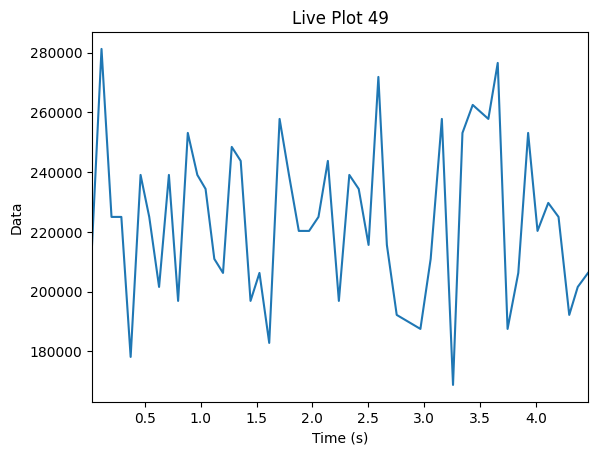

In [157]:
config = copy(default_config)

config.readout_integration_treg = 2**16-1 # Maxium number of integrated points
config.reps = 1 

prog = qd.PLIntensity(config) 

def get_cps():
    d = prog.acquire(progress=False)
    return d / qd.max_int_time_treg / qd.min_time_tns * 1e9

qd.live_plot(get_cps)

### PODMR

In [180]:
config = copy(default_config)

# MW pulse
# NQZ: 1 < 2.4925 GHz < 2 < 4.985 GHz
config.mw_pi_tns = 130

# Reps and Delays
config.pre_init = True 
config.reps = 600000

config.laser_on_tus = 2
config.laser_readout_offset_tus = 1.172
config.readout_integration_tns = 300
config.readout_reference_start_tus = 1.6
config.mw_laser_delay_treg = 0

config.relax_delay_tus = 1.1

config_lower = copy(config)

config_lower.mw_nqz = 1
config_lower.mw_gain = 1800
config_lower.mw_pi_tns = 650
center = 1808
width = 7
config_lower.add_linear_sweep('mw', 'fMHz', start=center-width, stop=center+width, delta=0.2)

# config_lower.mw_gain = 5000
# config_lower.mw_pi_tns = 200
# center = 1808
# width = 40
# config_lower.add_linear_sweep('mw', 'fMHz', start=center-width, stop=center+width, delta=0.8)


prog = qd.PODMR(config_lower)
d_under = prog.acquire()


# config_upper = copy(config)

# config_upper.mw_nqz = 2
# config_upper.mw_gain = 12000
# config_upper.mw_pi_tns = 186
# center = 3933
# width = 10
# config_upper.add_linear_sweep('mw', 'fMHz', start=center-width, stop=center+width, delta=0.3)

# prog = qd.PODMR(config_upper)
# d_over = prog.acquire()


Requested 1801 to 1815 by 0.2
Instead using 1800.9999996185302 to 1815.000026321411 by 0.20000038146972654 in 71 steps


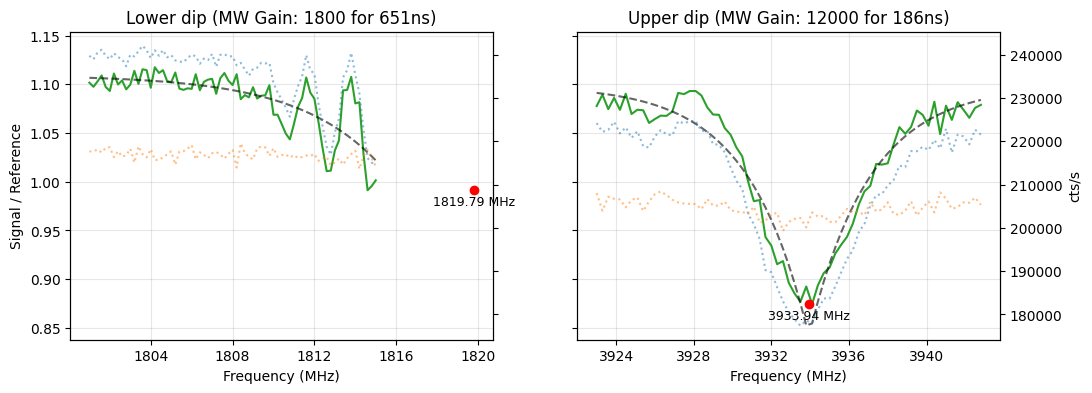

In [181]:
import numpy as np
import matplotlib.pyplot as plt

num_dips = 1

# --- Dip finding ---
def laplace_model(x, A, mu, b, C):
    return A * np.exp(-np.abs(x - mu) / b) + C

def fit_laplacian(freq, signal):
    A0 = np.min(signal) - 1
    mu0 = freq[np.argmin(signal)]
    b0 = np.sum(signal < 1 + A0/2) * (freq[1] - freq[0]) / (2 * np.log(2)) # half amplitude width 

    popt, _ = curve_fit(
        laplace_model,
        freq,
        signal,
        p0=[A0, mu0, b0, 1],
        maxfev=5000
    )

    A, mu, b, C = popt
    return A, mu, b, C

def plot_fit(freq, signal, axis):
    A, mu, b, C = fit_laplacian(freq, signal)
    fit_curve = laplace_model(freq, A, mu, b, C)

    axis.plot(freq, fit_curve, color='black', linestyle="--", alpha=0.6)

    # axis.plot(mu, C+A, 'ro')

    # axis.annotate(
    #     f"{mu:.2f} MHz",
    #     xy=(mu, C+A),
    #     xytext=(0, -11),
    #     textcoords="offset points",
    #     ha="center",
    #     fontsize=9
    # )

    ymin = signal[np.argmin(signal)]

    axis.plot(mu, ymin, 'ro')

    axis.annotate(
        f"{mu:.2f} MHz",
        xy=(mu, ymin),
        xytext=(0, -11),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

    return mu



# --- Compute ratios ---
ratio_under = d_under.signal / d_under.reference
ratio_over  = d_over.signal  / d_over.reference

dip_freqs = []

# =======================
# GLOBAL SCALING (CRITICAL)
# =======================

# Ratio (signal / reference)
ratio_all = np.concatenate((ratio_under, ratio_over))
rmin, rmax = np.nanmin(ratio_all), np.nanmax(ratio_all)
rpad = 0.15 * (rmax - rmin)
ratio_ylim = (rmin - rpad, rmax + rpad)

# Counts (signal + reference)
counts_all = np.concatenate((
    d_under.signal, d_under.reference,
    d_over.signal,  d_over.reference
))
cmin, cmax = np.nanmin(counts_all), np.nanmax(counts_all)
cpad = 0.05 * (cmax - cmin)
counts_ylim = (cmin - cpad, cmax + cpad)

# =======================
# FIGURE
# =======================

fig, (axL, axR) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(12, 4),
    gridspec_kw={"wspace": 0.2}
)

# =======================
# Left panel: Lower dip
# =======================

axL.plot(d_under.frequencies, ratio_under, color="tab:green")

axL.set_title(f"Lower dip (MW Gain: {config_lower.mw_gain:0.0f} for {config_lower.mw_pi_tns:0.0f}ns)")
axL.set_xlabel("Frequency (MHz)")
axL.set_ylabel("Signal / Reference")
axL.grid(alpha=0.3)

axL2 = axL.twinx()
axL2.plot(d_under.frequencies, d_under.signal,
          color="tab:blue", alpha=0.5, linestyle=":")
axL2.plot(d_under.frequencies, d_under.reference,
          color="tab:orange", alpha=0.5, linestyle=":")
axL2.tick_params(labelright=False)

plot_fit(d_under.frequencies, ratio_under, axL)

# =======================
# Right panel: Upper dip
# =======================

axR.plot(d_over.frequencies, ratio_over, color="tab:green")

axR.set_title(f"Upper dip (MW Gain: {config_upper.mw_gain:0.0f} for {config_upper.mw_pi_tns:0.0f}ns)")
axR.set_xlabel("Frequency (MHz)")
axR.grid(alpha=0.3)

axR2 = axR.twinx()
axR2.plot(d_over.frequencies, d_over.signal,
          color="tab:blue", alpha=0.5, linestyle=":")
axR2.plot(d_over.frequencies, d_over.reference,
          color="tab:orange", alpha=0.5, linestyle=":")
axR2.set_ylabel("cts/s")

plot_fit(d_over.frequencies, ratio_over, axR)


# =======================
# ENFORCE SHARED SCALING
# =======================

axL.set_ylim(ratio_ylim)
axR.set_ylim(ratio_ylim)

axL2.set_ylim(counts_ylim)
axR2.set_ylim(counts_ylim)

from matplotlib.ticker import MaxNLocator

for ax in [axL, axR]:
    ax.xaxis.set_major_locator(MaxNLocator(6))  # max 5 ticks

plt.show()



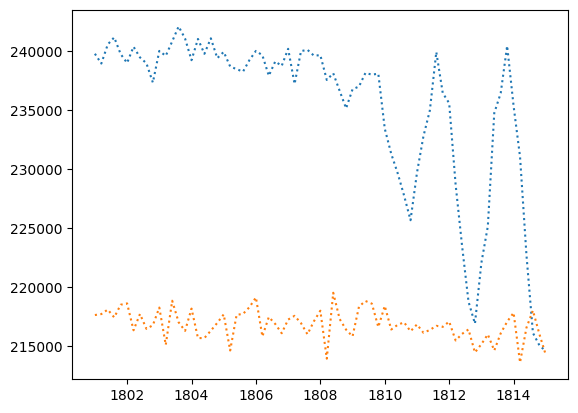

In [182]:
plt.plot(d_under.frequencies, d_under.signal,
          color="tab:blue", linestyle=":")
plt.plot(d_under.frequencies, d_under.reference,
          color="tab:orange", linestyle=":")

### RABI

In [98]:
config = copy(default_config)

config.relax_delay_tus = 2


config.mw_nqz = 1
config.mw_gain = 1800
config.mw_fMHz = 1738.8

config.pre_init=True

config.relax_delay_tus=0.5

config.laser_on_tus = 3 # in us
config.readout_integration_tns = 300  # us
config.readout_reference_start_tus = 2 # us

config.mw_readout_delay_treg = 35
config.laser_readout_offset_tus = 1.172 #

config.add_linear_sweep('mw', 'tns', start=15, stop=2000, delta=30)

config.reps = 1000000

prog = qd.RabiSweep(config)
d = prog.acquire(progress=True)


Requested 15 to 2000 by 30
Instead using 16.276041666666668 to 1949.8697916666667 by 29.296875 in 67 steps


100%|██████████| 67000000/67000000 [10:16<00:00, 108691.57it/s]


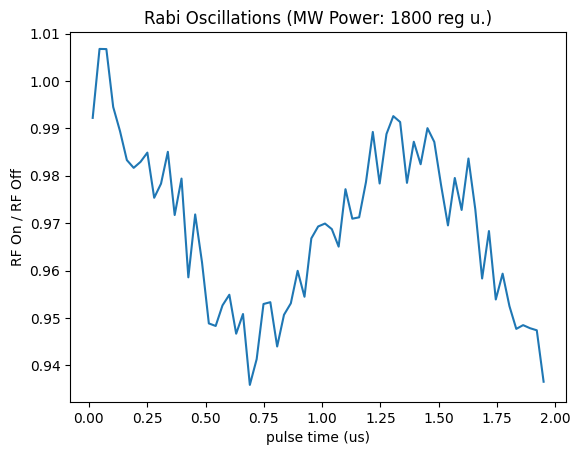

In [99]:
plt.plot(d.sweep_tus, d.signal1/d.signal2)

plt.title(f'Rabi Oscillations (MW Power: {config.mw_gain} reg u.)')
plt.ylabel('RF On / RF Off')
plt.xlabel('pulse time (us)')
plt.show()


Pi/2 pulse is approximately 336 ns
[0.02538838 1.34575703 0.96849766 6.88018761]


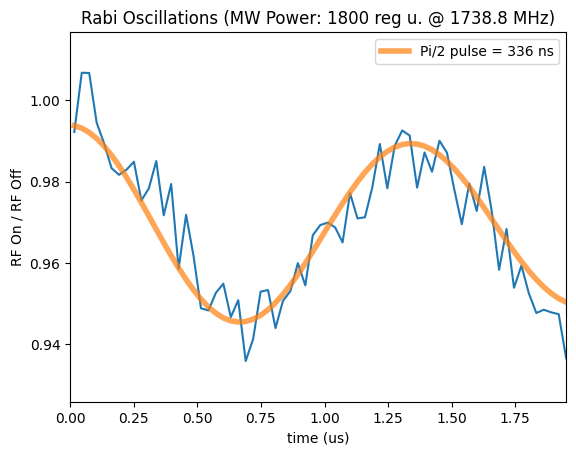

In [101]:
def decaying_cos(x, A, T, C, tau):

    return -A * (np.cos(x*2*np.pi/T- np.pi))*np.exp(-x/tau) + C

p0 = [0.5, 0.8, 0.95, 0.5]

t = d.sweep_tus
x = d.signal1/d.signal2

param, _ = curve_fit(decaying_cos, t, x, p0 = p0)

plt.plot(d.sweep_tus, d.signal1/d.signal2)

plt.plot(t, decaying_cos(t, *param), linewidth=4, alpha=0.7, label='Pi/2 pulse = {:.0f} ns'.format(param[1]*1000/4))
plt.title(f'Rabi Oscillations (MW Power: {config.mw_gain} reg u. @ {config.mw_fMHz:0.1f} MHz)')
plt.ylabel('RF On / RF Off')
plt.xlabel('time (us)')
plt.xlim(0, np.max(t))
plt.ylim(np.min(x)-0.01, np.max(x)+.01)
print('Pi/2 pulse is approximately {:.0f} ns'.format(param[1]*1000/4))
plt.vlines(param[1]/4, np.min(d.contrast), 0)
plt.legend()

print(param)
